In [10]:
## 기본 설정
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# 폰트 준비
import platform
# 운영체제를 확인하여 폰트 자동 지정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':  # Mac 환경
    plt.rc('font', family='Apple SD Gothic Neo')
print("설정완료")

설정완료


In [12]:

# ==========================================
# 변수 상관 분석 함수 
# ==========================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from statsmodels.stats.outliers_influence import variance_inflation_factor

def analyze_features(df, feature_cols, target_col, is_classification=True):
    """
    개선된 피처 분석 함수:
    - 수치형 피처 중심의 VIF 및 Mutual Information(상호 정보량) 기반 통합 분석 리포트 제공
    """
    df_analyzed = df.copy()
    
    # 1. 타겟 변수 안전 인코딩
    if is_classification and (df_analyzed[target_col].dtype in ['object', 'string', 'category']):
        le = LabelEncoder()
        df_analyzed[target_col] = le.fit_transform(df_analyzed[target_col].astype(str))
        
    # 범주형(문자열) 피처들을 숫자로 안전하게 인코딩 (MI 계산용)
    for col in feature_cols:
        if df_analyzed[col].dtype in ['object', 'string', 'category']:
            le_feat = LabelEncoder()
            df_analyzed[col] = le_feat.fit_transform(df_analyzed[col].astype(str))

    # 2. 수치형 피처만 구분하여 추출 (VIF 및 상관분석용)
    # 위에서 인코딩을 거쳤으므로 이제 모든 피처가 수치형으로 분류됩니다.
    numeric_features = [col for col in feature_cols if pd.api.types.is_numeric_dtype(df_analyzed[col])]
    
    if len(numeric_features) < len(feature_cols):
        ignored = set(feature_cols) - set(numeric_features)
        print(f"[주의] 수치형이 아닌 피처 {list(ignored)}는 VIF/상관관계 분석에서 제외되었습니다.")
        
    X_num = df_analyzed[numeric_features].copy()
    X_num = X_num.fillna(X_num.median())  # EDA용 결측치 임시 처리
    y = df_analyzed[target_col].fillna(df_analyzed[target_col].mode()[0])
    
    # 3. Mutual Information (비선형 포함 전체적인 의존도 측정)
    if is_classification:
        mi_scores = mutual_info_classif(X_num, y, random_state=42)
    else:
        mi_scores = mutual_info_regression(X_num, y, random_state=42)
        
    # 4. VIF 계산 (상수항 추가)
    X_vif = X_num.copy()
    X_vif['intercept'] = 1.0
    vif_list = []
    for i in range(X_num.shape[1]):
        try:
            vif = variance_inflation_factor(X_vif.values, i)
            vif_list.append(vif)
        except Exception:
            vif_list.append(np.nan)
            
    # 5. 리포트 생성
    report_df = pd.DataFrame({
        'Feature': numeric_features,
        'Mutual_Info': mi_scores,
        'Pearson_Corr_Abs': X_num.corrwith(y).abs().values,
        'VIF_Score': vif_list
    }).sort_values(by='Mutual_Info', ascending=False).reset_index(drop=True)
    
    # print("\n" + "="*60)
    # print(" [변수 분석 리포트] ")
    # print("="*60)
    # print(report_df.round(4))
    # print("="*60)
    print("* Tip: Mutual_Info가 높을수록 중요한 변수이며, VIF가 10 이상이면 다중공선성을 의심")

    return report_df

In [36]:
## 데이터 불러오기
PATH = 'data/titanic.csv'
df = pd.read_csv(PATH)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [37]:
num_features = ['Age', 'SibSp', 'Parch', 'Fare']
cat_features = ['Pclass', 'Sex', 'Embarked']
FEATURES = num_features + cat_features

In [38]:
analyze_features(df, FEATURES, 'Survived') 

* Tip: Mutual_Info가 높을수록 중요한 변수이며, VIF가 10 이상이면 다중공선성을 의심


,Feature,Mutual_Info,Pearson_Corr_Abs,VIF_Score
0,Sex,0.141100,0.543351,1.107806
1,Fare,0.138495,0.257307,1.647642
2,Pclass,0.044044,0.338481,1.680367
3,SibSp,0.028232,0.035322,1.283938
4,Age,0.022821,0.064910,1.213176
5,Parch,0.018094,0.081629,1.320805
6,Embarked,0.000000,0.163517,1.076900


Checking for overfitting...
Train ROC AUC score: 0.9978
Test ROC AUC score: 0.8117
Train Accuracy: 0.9761
Test Accuracy: 0.8156
Cross-validation ROC AUC scores:
CV ROC AUC mean score: 0.8569 (+/- 0.0288)
Confusion Matrix:


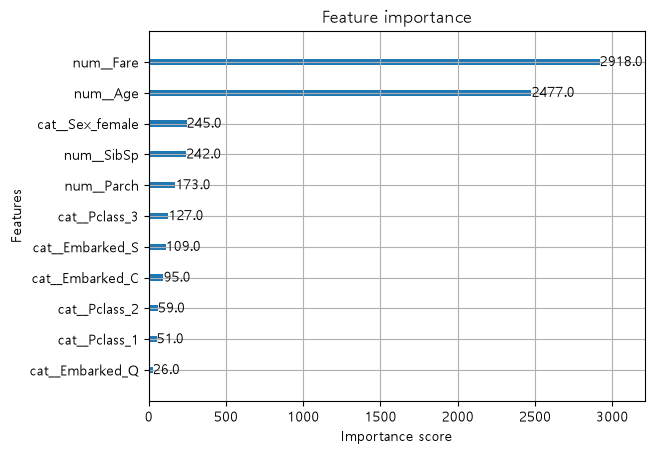

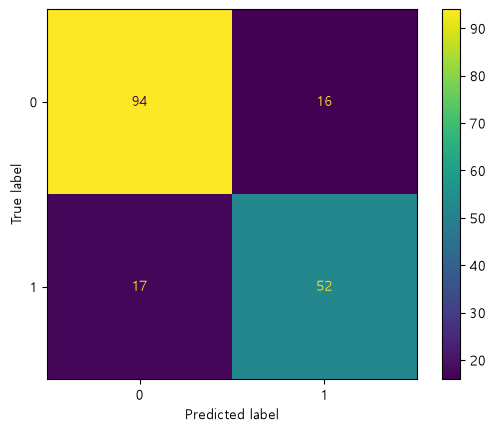

In [46]:
import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor
from xgboost import plot_importance, plot_tree
import matplotlib.pyplot as plt
import graphviz
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, recall_score, roc_curve, auc

SEED = 42

## x, y, X_test 준비
X = df[FEATURES]
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)  

## Pipeline 구성
num_features
cat_features

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  
    ('scaler', StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),   
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  
])
pipeline = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])
model = XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=6, random_state=SEED)  
model_pipeline = Pipeline(steps=[
    ('preprocessor', pipeline), 
    ('classifier', model) 
])
model_pipeline.fit(X_train, y_train)
preds = model_pipeline.predict(X_test)
probs = model_pipeline.predict_proba(X_test)[:,1]
train_preds = model_pipeline.predict(X_train)
train_probs = model_pipeline.predict_proba(X_train)[:,1]
#### 과적합 확인
print("Checking for overfitting...")
print(f"Train ROC AUC score: { roc_auc_score(y_train, train_probs):.4f}") 
print(f"Test ROC AUC score: { roc_auc_score(y_test, probs):.4f}")
print(f"Train Accuracy: { accuracy_score(y_train, train_preds):.4f}")
print(f"Test Accuracy: { accuracy_score(y_test, preds):.4f}")
#### Cross-validation 점수확인
cross_val = cross_val_score(model_pipeline, X_train, y_train, cv=5, scoring='roc_auc')
print("Cross-validation ROC AUC scores:" )
print('CV ROC AUC mean score: {:.4f} (+/- {:.4f})'.format(cross_val.mean(), cross_val.std()))
# print('avg CV score: {:.4f} (+/- {:.4f})'.format(cross_val.mean(), cross_val['score_time'].std()))
# print('avg CV test score: {:.4f} (+/- {:.4f})'.format(cross_val.mean(), cross_val['test_time'].std()))
#### 모델의 피쳐 중요도 시각화
feature_names = model_pipeline.named_steps['preprocessor'].get_feature_names_out()
classifier = model_pipeline.named_steps['classifier']
classifier.get_booster().feature_names = list(feature_names)
plot_importance(model_pipeline.named_steps['classifier'])
#### 혼돈 행렬 시각화
print("Confusion Matrix:")
cm = confusion_matrix(y_test, preds)    
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
print(classification_report(y_test, preds, digits=4))


In [21]:
X

,Age,SibSp,Parch,Fare,Pclass,Sex,Embarked
0,22.0,1,0,7.2500,3,male,S
1,38.0,1,0,71.2833,1,female,C
2,26.0,0,0,7.9250,3,female,S
3,35.0,1,0,53.1000,1,female,S
4,35.0,0,0,8.0500,3,male,S
...,...,...,...,...,...,...,...
886,27.0,0,0,13.0000,2,male,S
887,19.0,0,0,30.0000,1,female,S
888,NaN,1,2,23.4500,3,female,S
889,26.0,0,0,30.0000,1,male,C


In [ ]:
###################################################################
## 타이타닉 features engineering
###################################################################
def add_features(df):
    """Name, SibSp/Parch, Cabin으로부터 파생 변수를 만듭니다."""
    df = df.copy()

    # Name에서 호칭 추출: "Braund, Mr. Owen Harris" -> "Mr"
    df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
    df["Title"] = df["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
    # - Age 결측값: Title 기준 평균값으로 채우기
    df['Age'] = df.groupby('Title')['Age'].transform(
        lambda x: x.fillna(x.median())
    )
    # Title 모수가 적은 Title  Rare로 통일 :
    common = ["Mr", "Mrs", "Miss", "Master"]
    df["Title"] = df["Title"].where(df["Title"].isin(common), "Rare")

    # 가족 규모와 혼자 탑승 여부
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    df["IsAlone"] = (df["FamilySize"] == 1)

    # - Cabin 의 첫 글자(갑판) 추출하여 배구조정보 변수로 사용 --> NaN 값은 unknown 처리(기존에 없는 값)
    df['Deck'] = df['Cabin'].str[0]
    df['Deck'] = df['Deck'].fillna('Unknown')

    # Cabin은 77%가 결측이라 값을 채우는 대신, 정보가 있는지 여부를 변수로 씁니다.
    df["HasCabin"] = df["Cabin"].notnull()

    ### 성별과 객실 등급
    df['Sex_Pclass'] = df['Sex'].astype(str) + '_' + df['Pclass'].astype(str)

    # - Embarked 결측값 : 2%로 가장 많은 'S'값으로 처리
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

    return df


train_df = pd.read_csv(PATH + '/train.csv')
test_df = pd.read_csv(PATH + '/test.csv')
train_fe = add_features(train_df)
test_fe = add_features(test_df)
X = train_fe[FEATURES]
y = train_fe['Survived']
display(X)
display(y)
X_test = test_fe[FEATURES]
display(X_test)

num_features = ['Age',  'Fare', 'FamilySize'] #'SibSp', 'Parch',
cat_features = ['Pclass', 'Sex', 'Title', 'IsAlone', 'Deck', 'HasCabin', 'Sex_Pclass'] #, 'Embarked'
FEATURES = num_features + cat_features
train_fe[FEATURES]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone,Deck,HasCabin,Sex_Pclass
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,2,False,Unknown,False,male_3
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2,False,C,True,female_1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1,True,Unknown,False,female_3
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2,False,C,True,female_1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,1,True,Unknown,False,male_3


,Age,Fare,FamilySize,Pclass,Sex,Title,IsAlone,Deck,HasCabin,Sex_Pclass
0,22.0,7.2500,2,3,male,Mr,False,Unknown,False,male_3
1,38.0,71.2833,2,1,female,Mrs,False,C,True,female_1
2,26.0,7.9250,1,3,female,Miss,True,Unknown,False,female_3
3,35.0,53.1000,2,1,female,Mrs,False,C,True,female_1
4,35.0,8.0500,1,3,male,Mr,True,Unknown,False,male_3
...,...,...,...,...,...,...,...,...,...,...
886,27.0,13.0000,1,2,male,Rare,True,Unknown,False,male_2
887,19.0,30.0000,1,1,female,Miss,True,B,True,female_1
888,21.0,23.4500,4,3,female,Miss,False,Unknown,False,female_3
889,26.0,30.0000,1,1,male,Mr,True,C,True,male_1


Checking for overfitting...
Train ROC AUC score: 0.9429
Test ROC AUC score: 0.8541
Train Accuracy: 0.8919
Test Accuracy: 0.8156
Cross-validation ROC AUC scores:
CV ROC AUC mean score: 0.8836 (+/- 0.0118)
Confusion Matrix:
              precision    recall  f1-score   support

           0     0.8348    0.8727    0.8533       110
           1     0.7812    0.7246    0.7519        69

    accuracy                         0.8156       179
   macro avg     0.8080    0.7987    0.8026       179
weighted avg     0.8141    0.8156    0.8142       179



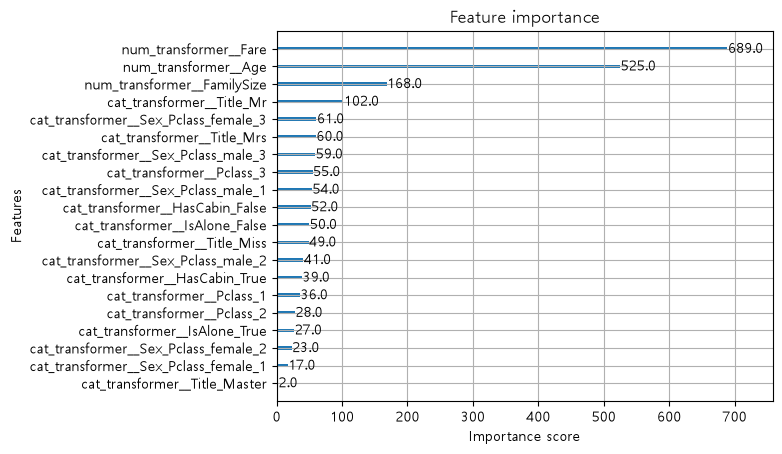

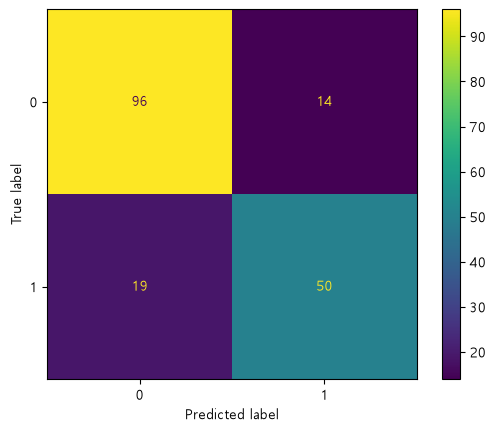

In [71]:
SEED = 42

num_features = ['Age',  'Fare', 'FamilySize'] #'SibSp', 'Parch',
cat_features = ['Pclass', 'Sex', 'Sex_Pclass' , 'Title', 'IsAlone', 'HasCabin'] #, 'Embarked' , 'Sex_Pclass' 'Deck','Sex'
FEATURES = num_features + cat_features
train_fe[FEATURES]

X = train_fe[FEATURES]
y = train_fe['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=SEED
)
num_transformer = Pipeline(
    steps=[
        ('num_imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)
cat_transformer = Pipeline(
    steps=[
        ('cat_imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        ('num_transformer', num_transformer, num_features),
        ('cat_transformer', cat_transformer, cat_features)
    ]
)
# model = XGBClassifier(
#     n_estimators=400, learning_rate=0.1, max_depth=6, random_state=SEED)
model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=5,
    gamma=0.1,
    subsample=0.8,
    colsample_bytree=0.6,
    colsample_bylevel=0.7,
    reg_alpha=0.1,
    reg_lambda=2.0,
    random_state=SEED
)
model_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', model) 
    ]
)
model_pipeline.fit(X_train, y_train)
preds = model_pipeline.predict(X_test)
probs = model_pipeline.predict_proba(X_test)[:,1]
train_preds = model_pipeline.predict(X_train)
train_probs = model_pipeline.predict_proba(X_train)[:,1]
#### 사용한 feature 확인
print("Used features:",FEATURES)

#### 과적합 확인
print("Checking for overfitting...")
print(f"Train ROC AUC score: { roc_auc_score(y_train, train_probs):.4f}") 
print(f"Test ROC AUC score: { roc_auc_score(y_test, probs):.4f}")
print(f"Train Accuracy: { accuracy_score(y_train, train_preds):.4f}")
print(f"Test Accuracy: { accuracy_score(y_test, preds):.4f}")
#### Cross-validation 점수확인
cross_val = cross_val_score(model_pipeline, X_train, y_train, cv=5, scoring='roc_auc')
print("Cross-validation ROC AUC scores:" )
print('CV ROC AUC mean score: {:.4f} (+/- {:.4f})'.format(cross_val.mean(), cross_val.std()))
# print('avg fit time: (+/- {})'.format(cross_val['fit_time'].mean(), cross_val['fit_time'].std()))
# print('avg score time: (+/- {})'.format(cross_val['score_time'].mean(), cross_val['score_time'].std()))
# print('avg test time: (+/- {})'.format(cross_val['test_time'].mean(), cross_val['test_time'].std()))
#### 모델의 피쳐 중요도 시각화
feature_names = model_pipeline.named_steps['preprocessor'].get_feature_names_out()
classifier = model_pipeline.named_steps['classifier']
classifier.get_booster().feature_names = list(feature_names)
plot_importance(model_pipeline.named_steps['classifier'])
#### 혼돈 행렬 시각화
print("Confusion Matrix:")
cm = confusion_matrix(y_test, preds)    
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
print(classification_report(y_test, preds, digits=4))

In [63]:
%pip install graphviz

Note: you may need to restart the kernel to use updated packages.


In [ ]:
graph = xgb.to_graphviz(model_pipeline.named_steps['classifier'], format='png')
graph

In [50]:
print(classification_report(y_test, preds, digits=4))

              precision    recall  f1-score   support

           0     0.8532    0.8455    0.8493       110
           1     0.7571    0.7681    0.7626        69

    accuracy                         0.8156       179
   macro avg     0.8052    0.8068    0.8060       179
weighted avg     0.8162    0.8156    0.8159       179



In [76]:
print(model_pipeline.named_steps.keys())

dict_keys(['preprocessor', 'classifier'])


In [78]:
### Fare, Age 편중되어 있음
### Fare, Age는 둘 다 연속형 변수라 트리 기반 모델이 분할 기준으로 삼기 쉬워서 과의존이 자주 발생합니다. 
### colsample_by* 계열과 max_depth, min_child_weight를 중심으로 그리드를 짜는 게 효과적입니다.
####1단계 방법 A: RandomizedSearchCV로 먼저 넓게 탐색 (권장)

from re import search

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

param_dist = {
    'classifier__max_depth': randint(3, 6),
    'classifier__min_child_weight': randint(2, 8),
    'classifier__learning_rate': uniform(0.02, 0.1),
    'classifier__subsample': uniform(0.6, 0.35),
    'classifier__colsample_bytree': uniform(0.4, 0.4),
    'classifier__colsample_bylevel': uniform(0.5, 0.4),
    'classifier__reg_lambda': uniform(1, 5),
    'classifier__gamma': uniform(0, 0.5),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
random_search = RandomizedSearchCV(
    estimator=model_pipeline,
    param_distributions=param_dist,
    n_iter=100,           # 시도 횟수
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=SEED
)

random_search.fit(X_train, y_train)
best_XGB_model = random_search.best_estimator_
print("Best params:", random_search.best_params_)
print(best_XGB_model)


Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best params: {'classifier__colsample_bylevel': np.float64(0.5027808522124763), 'classifier__colsample_bytree': np.float64(0.6042989210310263), 'classifier__gamma': np.float64(0.2087055015743895), 'classifier__learning_rate': np.float64(0.04221078104707303), 'classifier__max_depth': 5, 'classifier__min_child_weight': 3, 'classifier__reg_lambda': np.float64(2.6880758570181396), 'classifier__subsample': np.float64(0.9300183963693817)}
RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num_transformer',
                                                                               Pipeline(steps=[('num_imputer',
                                                                                                SimpleImputer(strategy='median')),
                 

In [93]:
num_features = ['Age',  'Fare', 'FamilySize'] #'SibSp', 'Parch',
cat_features = ['Pclass', 'Sex', 'Sex_Pclass' , 'Title', 'IsAlone', 'HasCabin'] #, 'Embarked' , 'Sex_Pclass' 'Deck','Sex'
FEATURES = num_features + cat_features
########################################################################
### 방법 B: 2단계 GridSearchCV (구조 → 정규화)
########################################################################

# 1단계: 트리 구조 관련 파라미터만 먼저 탐색
param_grid_1 = {
    'classifier__max_depth': [3, 4, 5, 6],
    'classifier__min_child_weight': [ 3, 5, 7, 9],
}

grid1 = GridSearchCV(best_XGB_model, param_grid_1, scoring='accuracy', cv=cv, n_jobs=-1)
grid1.fit(X_train, y_train)
best_depth = grid1.best_params_['classifier__max_depth']
best_mcw = grid1.best_params_['classifier__min_child_weight']
grid1_best_model = grid1.best_estimator_
print("Best params from grid1:", grid1.best_params_)    

# 2단계: 위 결과 고정 후 샘플링/정규화 파라미터 탐색
# base_model2 = XGBClassifier(
#     n_estimators=400,
#     max_depth=best_depth,
#     min_child_weight=best_mcw,
#     random_state=SEED,
#     eval_metric='logloss'
# )

param_grid_2 = {
    'classifier__colsample_bytree': [0.5, 0.6, 0.7],
    'classifier__colsample_bylevel': [0.6, 0.7, 0.8],
    'classifier__subsample': [0.7, 0.8, 0.9],
    'classifier__reg_lambda': [1, 2, 5],
}

grid2 = GridSearchCV(grid1_best_model, param_grid_2, scoring='accuracy', cv=cv, n_jobs=-1)
grid2.fit(X_train, y_train)
final_best_model = grid2.best_estimator_
print("Final best params:", {**grid1.best_params_, **grid2.best_params_})


Best params from grid1: {'classifier__max_depth': 5, 'classifier__min_child_weight': 3}
Final best params: {'classifier__max_depth': 5, 'classifier__min_child_weight': 3, 'classifier__colsample_bylevel': 0.8, 'classifier__colsample_bytree': 0.7, 'classifier__reg_lambda': 2, 'classifier__subsample': 0.9}


Checking for overfitting...
Train ROC AUC score: 0.9620
Test ROC AUC score: 0.8555
Train Accuracy: 0.9017
Test Accuracy: 0.8212
Cross-validation ROC AUC scores:
CV ROC AUC mean score: 0.8810 (+/- 0.0105)
Confusion Matrix:
              precision    recall  f1-score   support

           0     0.8421    0.8727    0.8571       110
           1     0.7846    0.7391    0.7612        69

    accuracy                         0.8212       179
   macro avg     0.8134    0.8059    0.8092       179
weighted avg     0.8199    0.8212    0.8202       179



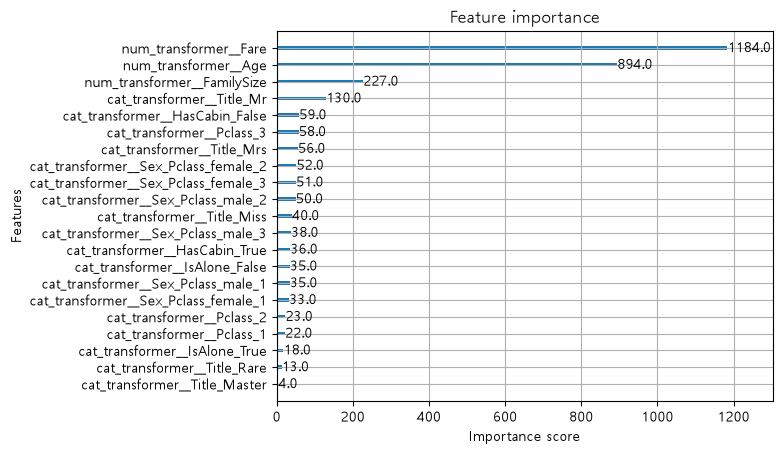

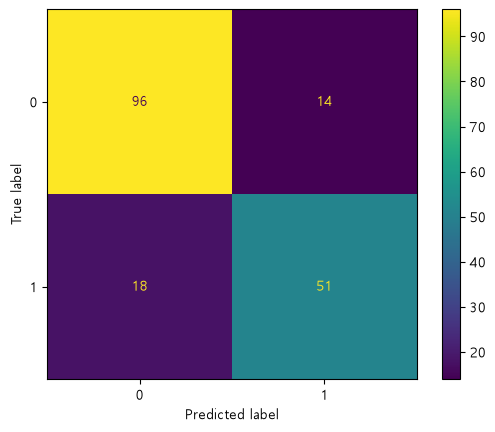

In [94]:
num_features = ['Age',  'Fare', 'FamilySize'] #'SibSp', 'Parch',
cat_features = ['Pclass', 'Sex_Pclass' , 'Title', 'IsAlone', 'HasCabin'] #, 'Embarked' , 'Sex_Pclass' 'Deck','Sex'
FEATURES = num_features + cat_features
train_fe[FEATURES]

X = train_fe[FEATURES]
y = train_fe['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=SEED
)

model_pipeline = final_best_model

model_pipeline.fit(X_train, y_train)
preds = model_pipeline.predict(X_test)
probs = model_pipeline.predict_proba(X_test)[:,1]
train_preds = model_pipeline.predict(X_train)
train_probs = model_pipeline.predict_proba(X_train)[:,1]
#### 사용한 feature 확인
print("Used features:",FEATURES)
#### 과적합 확인
print("Checking for overfitting...")
print(f"Train ROC AUC score: { roc_auc_score(y_train, train_probs):.4f}") 
print(f"Test ROC AUC score: { roc_auc_score(y_test, probs):.4f}")
print(f"Train Accuracy: { accuracy_score(y_train, train_preds):.4f}")
print(f"Test Accuracy: { accuracy_score(y_test, preds):.4f}")
#### Cross-validation 점수확인
cross_val = cross_val_score(model_pipeline, X_train, y_train, cv=5, scoring='roc_auc')
print("Cross-validation ROC AUC scores:" )
print('CV ROC AUC mean score: {:.4f} (+/- {:.4f})'.format(cross_val.mean(), cross_val.std()))
# print('avg fit time: (+/- {})'.format(cross_val['fit_time'].mean(), cross_val['fit_time'].std()))
# print('avg score time: (+/- {})'.format(cross_val['score_time'].mean(), cross_val['score_time'].std()))
# print('avg test time: (+/- {})'.format(cross_val['test_time'].mean(), cross_val['test_time'].std()))
#### 모델의 피쳐 중요도 시각화
feature_names = model_pipeline.named_steps['preprocessor'].get_feature_names_out()
classifier = model_pipeline.named_steps['classifier']
classifier.get_booster().feature_names = list(feature_names)
plot_importance(model_pipeline.named_steps['classifier'])
#### 혼돈 행렬 시각화
print("Confusion Matrix:")
cm = confusion_matrix(y_test, preds)    
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
print(classification_report(y_test, preds, digits=4))

In [114]:
FEATURES
print(type(model_pipeline))

<class 'sklearn.pipeline.Pipeline'>


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer    

def pipe(model, num_f: list[str], cat_f: list[str]) -> Pipeline:
    if not num_f and not cat_f:
        raise ValueError("num_f와 cat_f 중 최소 하나는 비어있으면 안 됩니다.")
    if model is None:
        raise ValueError("model 값이 비어있으면 안 됩니다.")
    if isinstance(num_f, str) or isinstance(cat_f, str):
        raise TypeError("num_f와 cat_f는 컬럼명의 리스트여야 합니다.")   
    overlap = set(num_f) & set(cat_f)
    if overlap:
        raise ValueError(f"num_f와 cat_f에 중복된 컬럼이 있습니다: {overlap}")

    num_transformer = Pipeline(
        steps=[
            ('num_imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]
    )
    cat_transformer = Pipeline(
        steps=[
            ('cat_imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) 
             #sparse_output=False => 결과가 일반 numpy 배열(dense)로 반환됨
        ]
    )
    preprocessor = ColumnTransformer(
        transformers=[
            ('num_transformer', num_transformer, num_f),
            ('cat_transformer', cat_transformer, cat_f)
        ],
        remainder='drop'  # or  passthrough
    )
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('estimator', model) ]
    )
 
    return model_pipeline


Used SEED/features: 42 / ['Age', 'Fare', 'FamilySize', 'Sex', 'Sex_Pclass', 'Title', 'IsAlone', 'Pclass', 'HasCabin']
Checking for overfitting...
Train ROC AUC score: 0.9502
Test ROC AUC score: 0.8235
Train Accuracy: 0.8943
Test Accuracy: 0.7985
Cross-validation ROC AUC scores:
CV ROC AUC mean score: 0.8882 (+/- 0.0271)
Confusion Matrix:
              precision    recall  f1-score   support

           0     0.8256    0.8554    0.8402        83
           1     0.7500    0.7059    0.7273        51

    accuracy                         0.7985       134
   macro avg     0.7878    0.7807    0.7838       134
weighted avg     0.7968    0.7985    0.7972       134



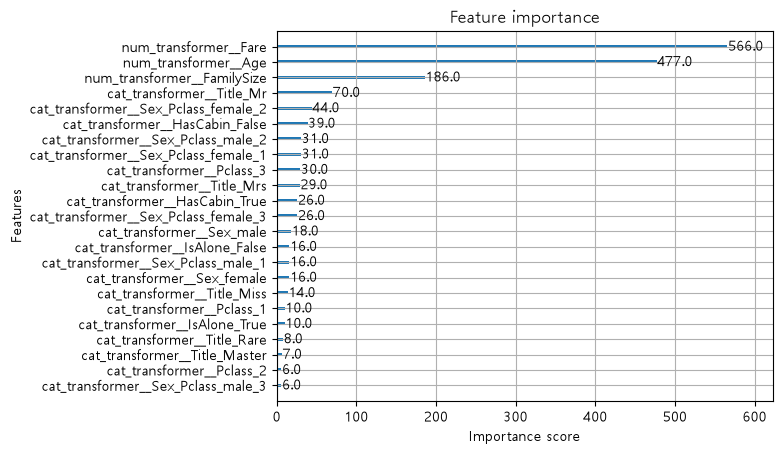

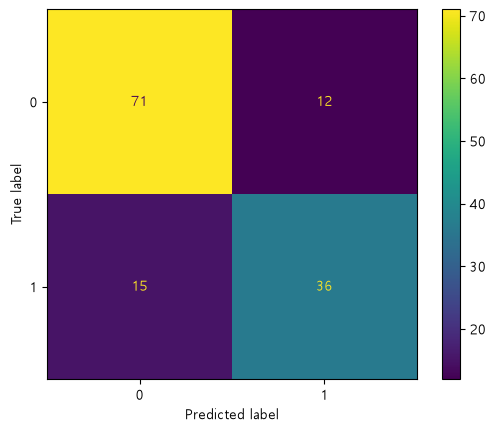

In [175]:
num_features = ['Age',  'Fare' , 'FamilySize'] #  ,'SibSp', 'Parch'
cat_features = ['Sex', 'Sex_Pclass', 'Title', 'IsAlone', 'Pclass','HasCabin'] #  , 'Deck','Embarked' 
# num_features = ['Age',  'Fare', 'FamilySize','SibSp', 'Parch'] # ,'SibSp', 'Parch',
# cat_features = ['Pclass', 'Sex_Pclass' ,'Sex', 'Title', 'IsAlone', 'HasCabin', 'Deck', 'Embarked'] #, 'Embarked' , '' 
FEATURES = num_features + cat_features
train_fe[FEATURES]
SEED = 42
X = train_fe[FEATURES]
y = train_fe['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.15, random_state=SEED
)
num_transformer = Pipeline(
    steps=[
        ('num_imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)
cat_transformer = Pipeline(
    steps=[
        ('cat_imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        ('num_transformer', num_transformer, num_features),
        ('cat_transformer', cat_transformer, cat_features)
    ]
)
# model = XGBClassifier(
#         max_depth= 5, 
#         min_child_weight= 3, 
#         colsample_bylevel= 0.8, 
#         colsample_bytree= 0.7, 
#         reg_lambda= 2, 
#         subsample= 0.9,
#         gamma=0.2,
#         learning_rate= 0.04
# )
model = XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=0.8, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=np.float64(0.2087055015743895),
              grow_policy=None, importance_type=None,
              interaction_constraints=None,
              learning_rate=np.float64(0.04221078104707303), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=3,  monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None)
model_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', model) 
    ]
)

model_pipeline.fit(X_train, y_train)
preds = model_pipeline.predict(X_test)
probs = model_pipeline.predict_proba(X_test)[:,1]
train_preds = model_pipeline.predict(X_train)
train_probs = model_pipeline.predict_proba(X_train)[:,1]
#### 사용한 feature 확인
print("Used SEED/features:",SEED,"/",FEATURES)
#### 과적합 확인
print("Checking for overfitting...")
print(f"Train ROC AUC score: { roc_auc_score(y_train, train_probs):.4f}") 
print(f"Test ROC AUC score: { roc_auc_score(y_test, probs):.4f}")
print(f"Train Accuracy: { accuracy_score(y_train, train_preds):.4f}")
print(f"Test Accuracy: { accuracy_score(y_test, preds):.4f}")
#### Cross-validation 점수확인
cross_val = cross_val_score(model_pipeline, X_train, y_train, cv=5, scoring='roc_auc')
print("Cross-validation ROC AUC scores:" )
print('CV ROC AUC mean score: {:.4f} (+/- {:.4f})'.format(cross_val.mean(), cross_val.std()))
# print('avg fit time: (+/- {})'.format(cross_val['fit_time'].mean(), cross_val['fit_time'].std()))
# print('avg score time: (+/- {})'.format(cross_val['score_time'].mean(), cross_val['score_time'].std()))
# print('avg test time: (+/- {})'.format(cross_val['test_time'].mean(), cross_val['test_time'].std()))
#### 모델의 피쳐 중요도 시각화
feature_names = model_pipeline.named_steps['preprocessor'].get_feature_names_out()
classifier = model_pipeline.named_steps['classifier']
classifier.get_booster().feature_names = list(feature_names)
plot_importance(model_pipeline.named_steps['classifier'])
#### 혼돈 행렬 시각화
print("Confusion Matrix:")
cm = confusion_matrix(y_test, preds)    
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
print(classification_report(y_test, preds, digits=4))

==== 모델별 기본 성능 비교 ==== random_state: 42

사용된 피쳐들: ['Sex_Pclass', 'Title', 'Sex', 'Pclass', 'HasCabin', 'IsAlone', 'Age', 'Fare', 'FamilySize']
기본 옵션으로 6가지 모델 테스트해 봤을 때 CV(scoring='accuracy')평균 점수가 LGBMClassifier가장 높음
|                   |F1-Score  |Precision    |Recall   |ROC-AUC   |CV_mean    |CV_std |
|-------------------|-----------|----------|----------|----------|----------|----------|
|LGBMClassifier     |0.771429   |0.760563  |0.782609  |0.843742  |0.830090  |0.018706
|LogisticRegres     |0.793893   |0.838710  |0.753623  |0.884321  |0.827263  |0.022839
|GradientBoosting   |0.748092   |0.790323  |0.710145  |0.833333  |0.821629  |0.021125
|RandomForest       |0.744526   |0.750000  |0.739130  |0.836627  |0.814616  |0.018457
|KNeighbors         |0.716418   |0.738462  |0.695652  |0.858498  |0.809012  |0.018220
|DecisionTree       |0.733813   |0.728571  |0.739130  |0.780303  |0.785108  |0.015195

In [171]:
PATH = 'C:/Users/dsbang/.cache/kagglehub/competitions/titanic'
train_df = pd.read_csv(PATH + '/train.csv')
test_df = pd.read_csv(PATH + '/test.csv')
train_fe = add_features(train_df)
test_fe = add_features(test_df)
X = train_fe[FEATURES]
y = train_fe['Survived']
X_test = test_fe[FEATURES]
display(X)
display(y)
display(X_test)

,Age,Fare,FamilySize,Sex,Sex_Pclass,Title,IsAlone,Pclass,HasCabin
0,22.0,7.2500,2,male,male_3,Mr,False,3,False
1,38.0,71.2833,2,female,female_1,Mrs,False,1,True
2,26.0,7.9250,1,female,female_3,Miss,True,3,False
3,35.0,53.1000,2,female,female_1,Mrs,False,1,True
4,35.0,8.0500,1,male,male_3,Mr,True,3,False
...,...,...,...,...,...,...,...,...,...
886,27.0,13.0000,1,male,male_2,Rare,True,2,False
887,19.0,30.0000,1,female,female_1,Miss,True,1,True
888,21.0,23.4500,4,female,female_3,Miss,False,3,False
889,26.0,30.0000,1,male,male_1,Mr,True,1,True


0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

,Age,Fare,FamilySize,Sex,Sex_Pclass,Title,IsAlone,Pclass,HasCabin
0,34.5,7.8292,1,male,male_3,Mr,True,3,False
1,47.0,7.0000,2,female,female_3,Mrs,False,3,False
2,62.0,9.6875,1,male,male_2,Mr,True,2,False
3,27.0,8.6625,1,male,male_3,Mr,True,3,False
4,22.0,12.2875,3,female,female_3,Mrs,False,3,False
...,...,...,...,...,...,...,...,...,...
413,28.5,8.0500,1,male,male_3,Mr,True,3,False
414,39.0,108.9000,1,female,female_1,Rare,True,1,True
415,38.5,7.2500,1,male,male_3,Mr,True,3,False
416,28.5,8.0500,1,male,male_3,Mr,True,3,False


In [172]:
#################################################
# XGBClassifier  하이터파라미터 튜닝 후 적용
#################################################
model = XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=0.8, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=np.float64(0.2087055015743895),
              grow_policy=None, importance_type=None,
              interaction_constraints=None,
              learning_rate=np.float64(0.04221078104707303), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=3,  monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None)
model_pipeline = Pipeline(
    steps=[
        ('processor', preprocessor),
        ('classifier', model)
    ]
)
model_pipeline.fit(X, y) #학습 
X_test = test_fe[FEATURES]
pred = model_pipeline.predict(X_test)

submission = pd.DataFrame({
    "PassengerId": test_fe["PassengerId"],
    "Survived": pred.astype(int),
})
submission.to_csv("submission.csv", index=False)
print(submission.shape)
submission.head()

(418, 2)


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [173]:
## 제출 2026-09-01 -6회차 전송
!kaggle competitions submit -c titanic -f submission.csv -m "baseline: XGBClassifier with Grid search2"


8 submissions remaining today.
Successfully submitted to Titanic - Machine Learning from Disaster



  0%|          | 0.00/3.18k [00:00<?, ?B/s]
100%|██████████| 3.18k/3.18k [00:00<00:00, 6.17kB/s]
100%|██████████| 3.18k/3.18k [00:01<00:00, 2.52kB/s]


In [174]:
# 제출 이력과 점수 확인  
!kaggle competitions submissions -c titanic

     ref  fileName        date                        description                                            status                     publicScore  privateScore  
--------  --------------  --------------------------  -----------------------------------------------------  -------------------------  -----------  ------------  
55943709  submission.csv  2026-09-01 16:14:46.473000  baseline: XGBClassifier with Grid search2              SubmissionStatus.COMPLETE  0.75837                    
55942732  submission.csv  2026-09-01 15:09:38.597000  baseline: XGBClassifier with Grid search               SubmissionStatus.COMPLETE  0.75837                    
55920164  submission.csv  2026-08-31 16:39:49.617000  baseline: RandomForest with Grid search                SubmissionStatus.COMPLETE  0.74880                    
55920100  submission.csv  2026-08-31 16:35:57.350000  baseline: LogisticRegression with Grid search          SubmissionStatus.COMPLETE  0.75598                    
55916941  submis

In [ ]:
################################################################################
## pipeline 함수
################################################################################
import pandas as pd
from pandas.api.types import is_numeric_dtype
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer    

def pipe(model, num_f: list[str], cat_f: list[str], X ) -> Pipeline:
    if not num_f and not cat_f:
        raise ValueError("num_f와 cat_f 중 최소 하나는 비어있으면 안 됩니다.")
    if model is None:
        raise ValueError("model 값이 비어있으면 안 됩니다.")
    if not isinstance(X, pd.DataFrame):
        raise TypeError("X는 pandas DataFrame이어야 합니다.")    
    if isinstance(num_f, str) or isinstance(cat_f, str):
        raise TypeError("num_f와 cat_f는 컬럼명의 리스트여야 합니다.")   
    overlap = set(num_f) & set(cat_f)
    if overlap:
        raise ValueError(f"num_f와 cat_f에 중복된 컬럼이 있습니다: {overlap}")
    
    # num_f, cat_f가 실제 X에 존재하는 컬럼인지 확인
    missing_cols = (set(num_f) | set(cat_f)) - set(X.columns)
    if missing_cols:
        raise ValueError(f"X에 존재하지 않는 컬럼입니다: {missing_cols}")

    # num_f가 실제 숫자형인지 확인
    #non_numeric = [col for col in num_f if not is_numeric_dtype(X[col])] # bool 도 숫자로 인식
    non_numeric = [
        col for col in num_f 
        if not is_numeric_dtype(X[col]) or pd.api.types.is_bool_dtype(X[col]) ## bool 티입도 제외
    ]
    if non_numeric:
        raise TypeError(f"num_f에 숫자형이 아닌 컬럼이 있습니다: {non_numeric}")
    
    num_transformer = Pipeline(
        steps=[
            ('num_imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]
    )
    cat_transformer = Pipeline(
        steps=[
            ('cat_imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) 
             #sparse_output=False => 결과가 일반 numpy 배열(dense)로 반환됨
        ]
    )
    preprocessor = ColumnTransformer(
        transformers=[
            ('num_transformer', num_transformer, num_f),
            ('cat_transformer', cat_transformer, cat_f)
        ],
        remainder='drop'  # or  passthrough
    )
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('estimator', model) ]
    )
 
    return model_pipeline

############## 호출 예시 ##############
"""
model_pipeline = pipe(model=my_model, num_f=num_features, cat_f=cat_features, X=X_train)
model_pipeline.fit(X_train, y_train)
"""

################################################################################
## 학습 및 예측 함수
################################################################################
def fit_and_predict(pipeline, X_train, y_train, X_test):
    """조립된 파이프라인을 받아 학습/예측만 수행"""
    pipeline.fit(X_train, y_train)

    preds = pipeline.predict(X_test)
    #probs = pipeline.predict_proba(X_test)[:,1] #미지원 모델(예: 일부 SVM 설정)을 위해 조건 처리
    if hasattr(pipeline.named_steps['estimator'], 'predict_proba'):
        probs = pipeline.predict_proba(X_test)[:, 1]
    else:
        probs = None   
    train_preds = pipeline.predict(X_train)
    train_probs = pipeline.predict_proba(X_train)[:,1]

    return pipeline, preds, probs, train_preds, train_probs

################################################################################
## 학습 시간 기록 함수
################################################################################
import time

def compare_models_with_timing(models, num_f, cat_f, X_train, y_train, X_test, y_test):
    results = []
    for name, model in models.items():
        pipeline = pipe(model=model, num_f=num_f, cat_f=cat_f, X=X_train)
        
        start = time.time()
        pipeline.fit(X_train, y_train)
        fit_time = time.time() - start
        
        start = time.time()
        y_pred = pipeline.predict(X_test)
        predict_time = time.time() - start
        
        results.append({
            'model': name,
            'fit_time_sec': fit_time,
            'predict_time_sec': predict_time,
        })
    return pd.DataFrame(results)


################################################################################
## 리포트 및 시각화 함수
################################################################################
import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor
from xgboost import plot_importance, plot_tree
import matplotlib.pyplot as plt
import graphviz
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, recall_score, roc_curve, auc

def plot_feature_importance(model_pipeline):
    feature_names = model_pipeline.named_steps['preprocessor'].get_feature_names_out()
    estimator = model_pipeline.named_steps['estimator']

    if hasattr(estimator, 'feature_importances_'):
        importances = estimator.feature_importances_
    elif hasattr(estimator, 'coef_'):
        importances = estimator.coef_.ravel()
    else:
        print(f"{type(estimator).__name__}은(는) 중요도 시각화를 지원하지 않습니다.")
        return

    plt.barh(feature_names, importances)
    plt.tight_layout()
    plt.show()

def train_pred_test_reports(model_pipeline, X_train, y_train, preds, probs, train_preds, train_probs,seed=SEED, features=FEATURES):
    #### 사용한 SEED & feature 확인
    print("Used SEED/features:",seed,"/",features)

    #### 과적합 확인
    print("Checking for overfitting...")
    print(f"Train ROC AUC score: { roc_auc_score(y_train, train_probs):.4f}") 
    print(f"Test ROC AUC score: { roc_auc_score(y_test, probs):.4f}")
    print(f"Train Accuracy: { accuracy_score(y_train, train_preds):.4f}")
    print(f"Test Accuracy: { accuracy_score(y_test, preds):.4f}")

    #### Cross-validation 점수확인
    #cross_val = cross_val_score(model_pipeline, X_train, y_train, cv=5, scoring='roc_auc')
    cv_result = cross_validate(model_pipeline, X_train, y_train, cv=5, scoring='roc_auc')
    print("Cross-validation ROC AUC scores:" )
    print('CV ROC AUC mean: {:.4f} (+/- {:.4f})'.format(
        cv_result['test_score'].mean(), cv_result['test_score'].std()))
    print('Avg fit time: {:.4f}s (+/- {:.4f})'.format(
        cv_result['fit_time'].mean(), cv_result['fit_time'].std()))
    print('Avg score time: {:.4f}s (+/- {:.4f})'.format(
        cv_result['score_time'].mean(), cv_result['score_time'].std()))

    # #### 모델의 피쳐 중요도 시각화 #XGBoost 모델 전용
    # feature_names = model_pipeline.named_steps['preprocessor'].get_feature_names_out()
    # classifier = model_pipeline.named_steps['estimator']
    # classifier.get_booster().feature_names = list(feature_names) #XGBoost 모델 전용
    # plot_importance(model_pipeline.named_steps['estimator']) #XGBoost 모델

    #### 모델의 피쳐 중요도 시각화
    plot_feature_importance(model_pipeline)

    #### 혼돈 행렬 시각화
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, preds)    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.show()

    #### classification_report  
    print(classification_report(y_test, preds, digits=4))



################################################################################
## 하이퍼파라미터 튜닝 함수
################################################################################
from sklearn.model_selection import GridSearchCV

def tune_model(model, param_grid, num_f, cat_f, X, y, cv=5, scoring='f1'):
    pipeline = pipe(model=model, num_f=num_f, cat_f=cat_f)
    # 파이프라인 내부 estimator 파라미터 접근 시 'estimator__' 접두어 필요
    grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring=scoring, n_jobs=-1)
    grid.fit(X, y)
    return grid.best_estimator_, grid.best_params_, grid.best_score_ 


################################################################################
## 여러모델 비교 함수
################################################################################   
from sklearn.model_selection import cross_validate
import pandas as pd

def compare_models(models: dict, num_f, cat_f, X, y, cv=5, scoring=['accuracy', 'f1', 'roc_auc']):
    """
    models: {'모델이름': model_object} 형태의 딕셔너리
    """
    results = []
    for name, model in models.items():
        pipeline = pipe(model=model, num_f=num_f, cat_f=cat_f)
        cv_result = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, return_train_score=False)
        
        row = {'model': name}
        for metric in scoring:
            row[f'{metric}_mean'] = cv_result[f'test_{metric}'].mean()
            row[f'{metric}_std'] = cv_result[f'test_{metric}'].std()
        results.append(row)
    
    return pd.DataFrame(results).sort_values(by=f'{scoring[0]}_mean', ascending=False)

##############사용 예시#########################
""" 
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42)
}

results_df = compare_models(models, num_features, cat_features, X_train, y_train)
print(results_df)
"""

In [ ]:
Votting 가중치 샘플링 sample_weight
XG Boosting: 작은/단순 모델로 부터 시작 --> 오답 검토 -> 오답 가중치
-- learning rate - 보폭을 작계하면 - 오답 노트를 작계 반복한다 --> 많은 모델이 필요
Gradient booting: 여러모델리 순차 보정

성능이 비슷할 때 
- cv , std , cv acc , train acc 
- 모델 기준에서 검토 사항
----> 모델별 피쳐 중요성 
----> 미탐 오탐 혼돈 메트릭스  
----> 정답의 공통점 vs 다른점 
----> 오답의 공통점 vs 다른점 